**Simple linear regression**

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
%matplotlib inline

we plot price vs variables to look for candidates

MSSubClass


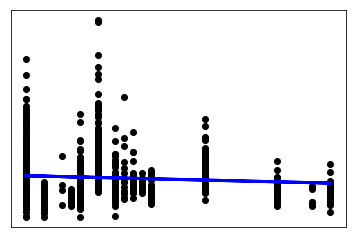

LotArea


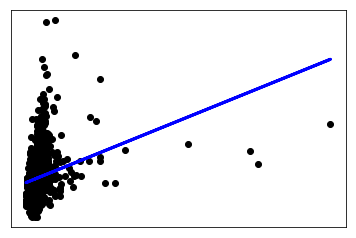

OverallQual


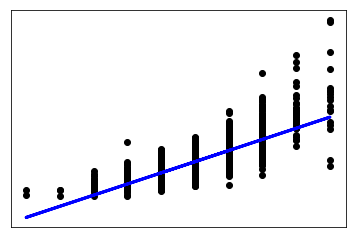

OverallCond


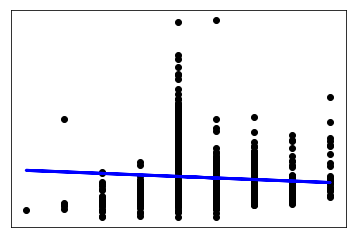

YearBuilt


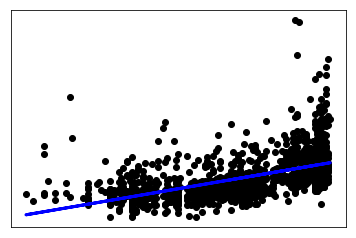

YearRemodAdd


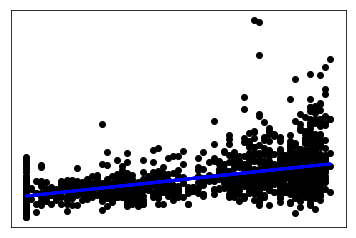

BsmtFinSF1


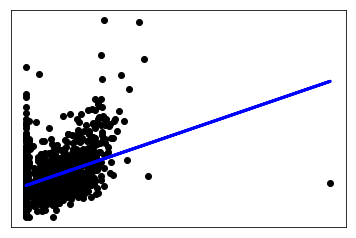

BsmtFinSF2


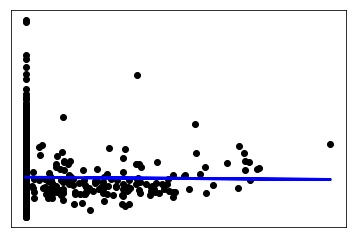

BsmtUnfSF


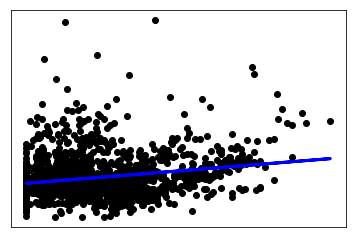

TotalBsmtSF


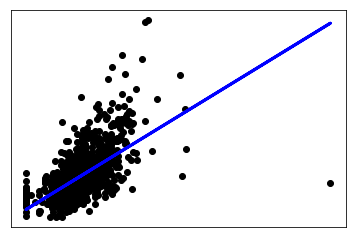

1stFlrSF


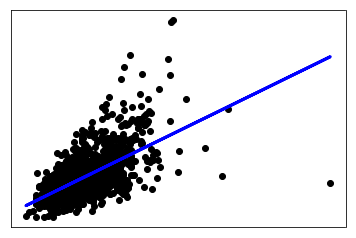

2ndFlrSF


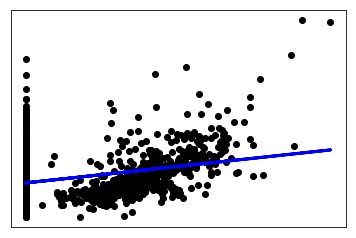

LowQualFinSF


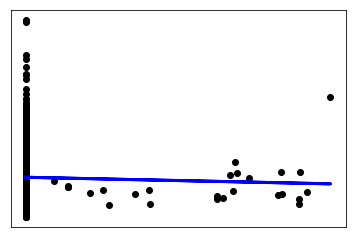

GrLivArea


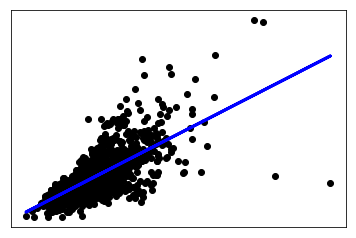

BsmtFullBath


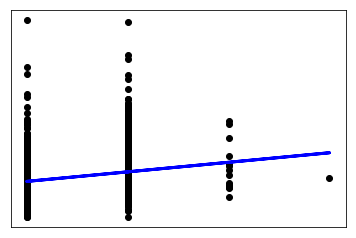

BsmtHalfBath


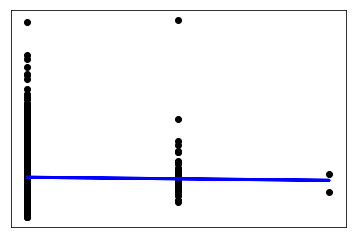

FullBath


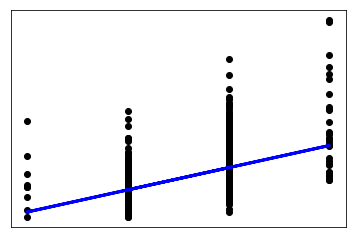

HalfBath


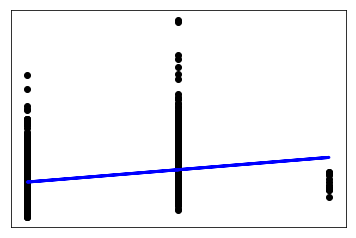

BedroomAbvGr


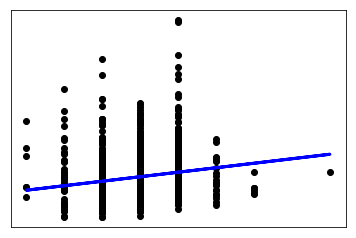

KitchenAbvGr


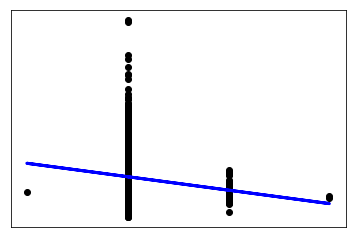

TotRmsAbvGrd


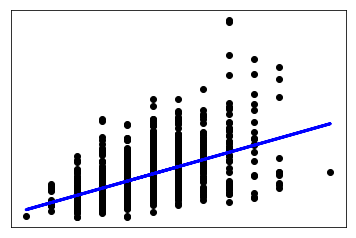

Fireplaces


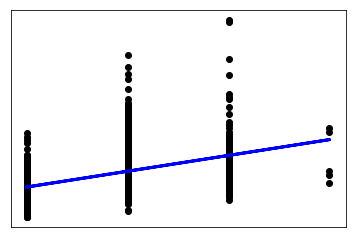

GarageCars


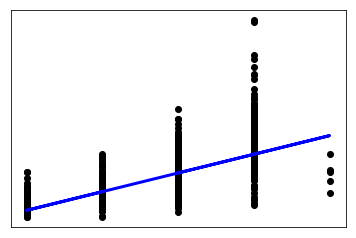

GarageArea


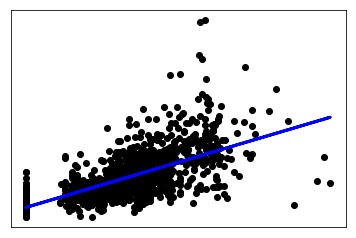

WoodDeckSF


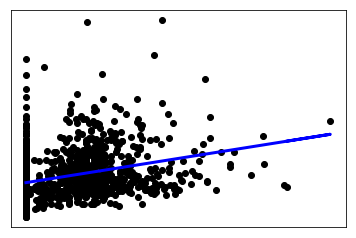

OpenPorchSF


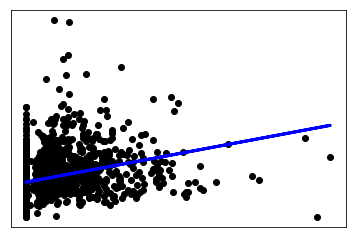

EnclosedPorch


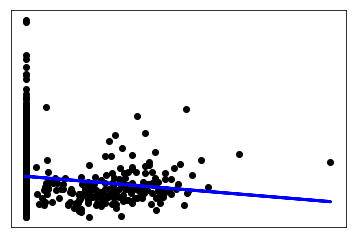

3SsnPorch


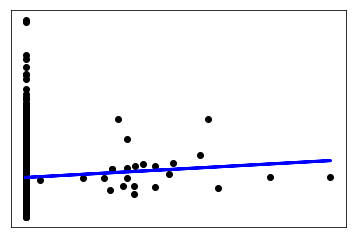

ScreenPorch


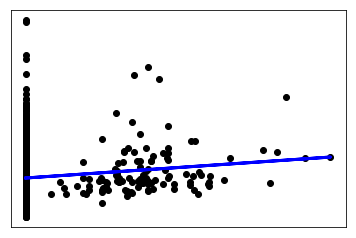

PoolArea


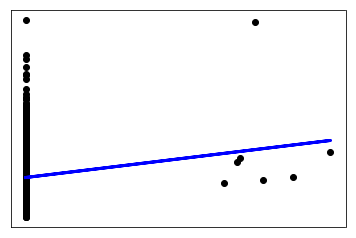

MiscVal


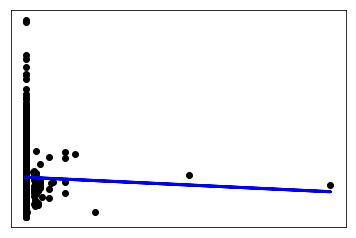

MoSold


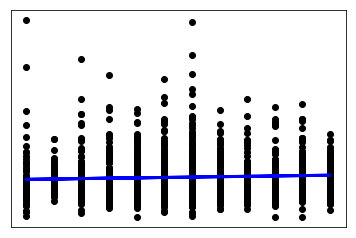

YrSold


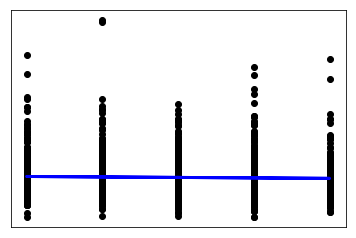

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y = train.SalePrice.values
y = y.reshape(y.shape[0], 1)

columns = train.columns.values

for i in range(1, columns.size):
    if (columns[i] != "SalePrice"):
        x = train[columns[i]].values
        if (not isinstance(x[0], str) and not np.isnan(x[0])):
            x = x.reshape(x.shape[0], 1)
            try:
                regr = LinearRegression()
                regr.fit(x, y)
                print(columns[i])                
                plt.scatter(x, y,  color='black')
                plt.plot(x, regr.predict(x), color='blue', linewidth=3)
                plt.xticks(())
                plt.yticks(())
                plt.show()
            except ValueError:
                pass

we choose one and make a prediction

In [3]:
x = train.GrLivArea.values
x = x.reshape(x.shape[0], 1)
regr = LinearRegression()
regr.fit(x, y)

x_ids = test.Id.values
x_ids = x_ids.reshape(x_ids.shape[0], 1)
x_t = test.GrLivArea.values
x_t = x_t.reshape(x_t.shape[0], 1)
sale_prices = regr.predict(x_t)

submission = np.hstack((x_ids, sale_prices))

with open('asdf2.csv','wb') as file:
    file.write(("Id,SalePrice\n").encode())
    for row in submission:
        file.write((str(int(row[0]))+","+str(row[1])+"\n").encode())

multiple regression

In [20]:
x1 = train[["GrLivArea", "YearBuilt"]]

y1 = train.SalePrice.values
y1 = y1.reshape(y1.shape[0], 1)

regr1 = LinearRegression()
regr1.fit(x1, y1)

x1_ids = test.Id.values
x1_ids = x1_ids.reshape(x1_ids.shape[0], 1)
x12_t = test[["GrLivArea", "YearBuilt"]]

sale_prices1 = regr1.predict(x12_t)
submission1 = np.hstack((x1_ids, sale_prices1))

with open('asdf3.csv','wb') as file:
    file.write(("Id,SalePrice\n").encode())
    for row in submission:
        file.write((str(int(row[0]))+","+str(row[1])+"\n").encode())